In [25]:
library(data.table)
library(ggplot2)
library(ggrepel)
setwd('/well/lindgren/UKBIOBANK/flassen/projects/KO/wes_ko_ukbb')

In [64]:
files = list.files('data/saige/output/combined/binary/step2/', full.names = TRUE)
#x <- fread('data/saige/output/combined/binary/step2//ukb_wes_200k_af50_ptv_coronary_artery_disease_chr1')
#y <- fread('data/saige/output/combined/binary/step2//ukb_wes_200k_af50_ptv_damaging_missense_coronary_artery_disease_chr1')
#print(head(x$p.value)); print(head(y$p.value))
files = list.files('data/saige/output/combined/old/binary/step2/', full.names = TRUE)
files

[1] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr10"                                                   
   [2] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr11"                                                   
   [3] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr12"                                                   
   [4] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr13"                                                   
   [5] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr14"                                                   
   [6] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr15"                                                   
   [7] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr16"                                                   
   [8] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr17"                                                   
   [9] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr18"                                                   
  [10] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr19"                                                   
  [11] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr20"                                                   
  [12] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr21"                                                   
  [13] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr22"                                                   
  [14] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr3"                                                    
  [15] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr4"                                                    
  [16] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr5"                                                    
  [17] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr6"                                                    
  [18] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr7"                                                    
  [19] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr8"                                                    
  [20] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_ADHD_chr9"                                                    
  [21] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr1"                                      
  [22] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr10"                                     
  [23] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr11"                                     
  [24] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr12"                                     
  [25] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr13"                                     
  [26] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr14"                                     
  [27] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr15"                                     
  [28] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr16"                                     
  [29] "data/saige/output/combined/old/binary/step2//ukb_wes_200k_af50_ptv_Alzheimers_disease_chr17"                                     
 

In [49]:
build_dt_by_keyword <- function(files, phenotype = 'Crohns'){
    categories <- c('ptv','ptv_damaging_missense','synonymous')
    csq_list <- lapply(categories, function(category){
        regex <- paste0(category,'_',phenotype) 
        csqs_files <- files[grepl(regex, files)]
        mat <- do.call(rbind, lapply(csqs_files, function(f){
            return(fread(f))
        }))
        n <- nrow(mat)
        mat$csqs <- category
        mat$FDR <- stats::p.adjust(mat$p.value, method = 'fdr')
        mat <- mat[order(mat$p.value),]
        mat$p.value.observed <- mat$p.value
        mat$p.value.expected <- seq(1, n)/(n + 1)
        
        mat$label <- NA
        mat$label[mat$SNPID %in% head(mat$SNPID, n = 2)] <- mat$SNPID
        
        return(mat)
    })
    names(csq_list) <- categories
    return(csq_list)
}

In [65]:
lst <- build_dt_by_keyword(files, 'Cirrhosis')
mat <- do.call(rbind, lst)

Warning message in mat$label[mat$SNPID %in% head(mat$SNPID, n = 2)] <- mat$SNPID:
"number of items to replace is not a multiple of replacement length"
Warning message in mat$label[mat$SNPID %in% head(mat$SNPID, n = 2)] <- mat$SNPID:
"number of items to replace is not a multiple of replacement length"
Warning message in mat$label[mat$SNPID %in% head(mat$SNPID, n = 2)] <- mat$SNPID:
"number of items to replace is not a multiple of replacement length"


In [66]:
mat$label[!is.na(mat$label)]

[1] "ENSG00000188162" "ENSG00000183111" "ENSG00000010704" "ENSG00000157388"
[5] "ENSG00000112343" "ENSG00000165626"

Warning message:
"Removed 11752 rows containing missing values (geom_text_repel)."


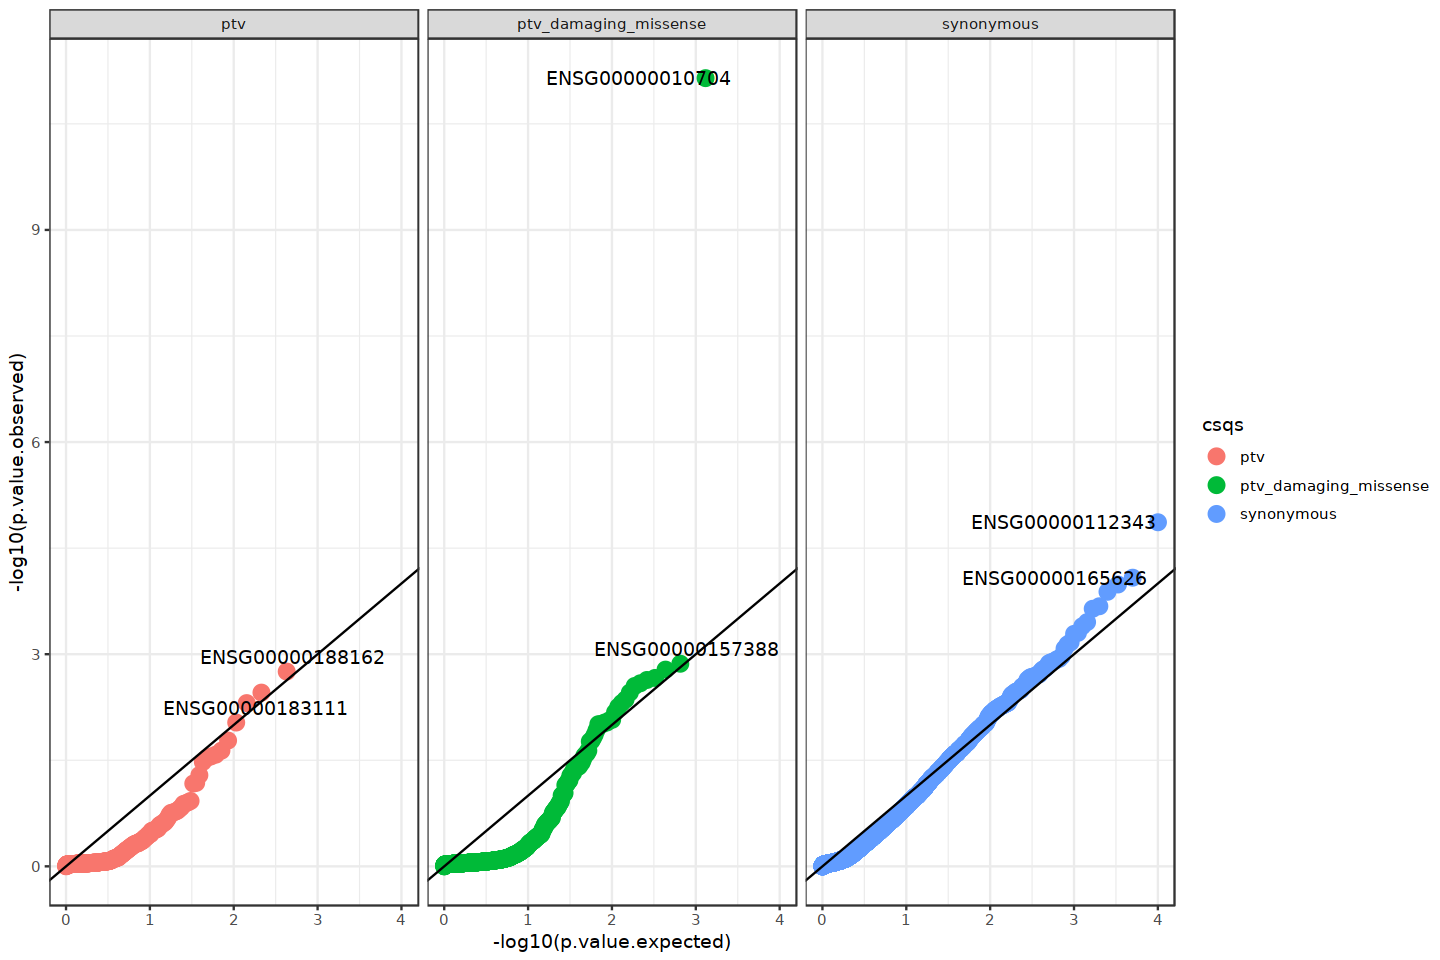

In [67]:
options(repr.plot.width=12, repr.plot.height=8)
ggplot(mat, aes(x=-log10(p.value.expected), y=-log10(p.value.observed), color = csqs, label = label)) + 
    geom_point(size = 4) + 
    geom_abline() +
    geom_text_repel(color='black') +
    theme_bw() +
    facet_wrap(~csqs) 